# Week 4: Baseline Model
- Train a linear regression as the first model
- Evaluate using R^2 on test set
- Record baseline results

A random seed is added for reproducability.

Leakage varaibles are again removed to ensure no sensitive information is leaked. Additionally, variables that would have been known only after CloseDate are removed.

A linear regression was trained as a first model to use as a baseline of comparison for further machine learning models. We expect these models to perform to explain more of the correlation in the data than the linear regression.

Baseline results are noted and explained after the linear regression is performed and a plot is included for visualization.

In [45]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path
import random
import numpy as np
np.random.seed(42)
random.seed(42)


In [47]:
# loading in test/train split data
filepath = r"C:\Users\julia\downloads\IDX_summer_internship"
train_df = pd.read_csv(filepath + r"\train_cleaned.csv", low_memory=False)
test_df = pd.read_csv(filepath + r"\test_cleaned.csv", low_memory=False)

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows:  {len(test_df):,}")
print(f"Columns: {train_df.shape[1]}")

Training rows: 313,288
Testing rows:  11,844
Columns: 55


In [48]:
print("done")

done


In [49]:
# chosing target variable, creating x and y

target = "ClosePrice"
x_train = train_df.drop(columns=["ClosePrice"]) # we want to train on ClosePrice so we remove it here
x_test = test_df.drop(columns=["ClosePrice"])

y_train = train_df['ClosePrice']
y_test = test_df['ClosePrice']

drop_cols = [                   # these are based on what Aidan said in the slack
    "CloseDate",                # stuff like days on market are only known after the close
    "ListPrice",                # everything else introduces leakages
    "OriginalListPrice",
    "ListingKey",
    "ListingKeyNumeric",
    "DaysOnMarket",
    "HighSchoolDistrict"
]

x_train = x_train.drop(columns=drop_cols, errors="ignore") # dropping the rest of the leakage or unnecessary columns
x_test = x_test.drop(columns=drop_cols, errors="ignore")


In [50]:
# training the linear regression model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

LinearRegression()

In [51]:
# predict on the test set
y_pred = lr.predict(x_test)

# Evaluating Model Performance
To measure the performance of the baseline model the following primary evaluation metrics are:
- R² – Measures how well the model explains the variation in home prices.
- MAPE – Measures the average percentage prediction error.
- MdAPE – Measures the median percentage prediction error and is less affected by extreme values.
- MAE – The average prediction error in dollars.
- RMSE – A metric that places greater emphasis on larger prediction errors.

In [53]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "MAPE": mape, "MdAPE": mdape}

y_pred = lr.predict(x_test)
results = evaluate_model(y_test, y_pred, label="Linear Regression Baseline")


Linear Regression Baseline
R²:    0.4774
RMSE:  $663,278
MAE:   $438,910
MAPE:  42.95%
MdAPE: 29.92%


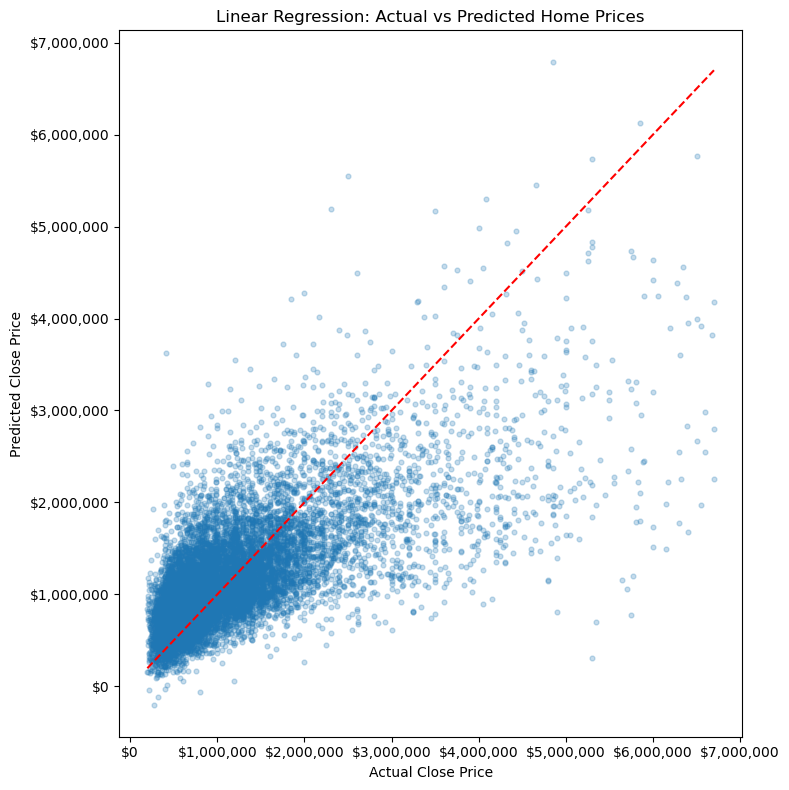

In [62]:
from matplotlib.ticker import StrMethodFormatter

# predicted vs actual plot
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.25,
    s=12
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Linear Regression: Actual vs Predicted Home Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()